In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

---
## Filter the SNR Catalog

1. Read the original SNR catalog from `snr.csv` into a pandas DataFrame called `df`.
2. Select only the rows with galactic longitude `l_deg` between 60 and 270 degrees.
3. Save the filtered results to a new file, `snr_longitude_filtered_df.csv`.

This produces the subset of remnants used in the age calculations.

In [10]:
df = pd.read_csv("snr.csv")

if 'snr_longitude_filtered_df' not in globals():
    snr_longitude_filtered_df = df[(df['l_deg'] >= 60) & (df['l_deg'] <= 270)].copy()
    snr_longitude_filtered_df.to_csv("snr_longitude_filtered_df.csv", index=False)

---

## Sedov–Taylor Age Equation

Starting from the Sedov–Taylor radius equation,
$$
R(t) = \left( \frac{25}{3\pi} \right)^{1/5} \left(\frac{E_{\text{SN}}}{\rho_0}\right)^{1/5} t^{2/5}
$$

solving for the age gives
$$
t=\left(\frac{R}{\left(\frac{25}{3\pi}\right)^{1/5}\left(\frac{E_{\text{SN}}}{\rho_0}\right)^{1/5}}\right)^{5/2}.
$$

Equivalently,
$$
t=\left(\frac{3\pi}{25}\right)^{1/2}
\left(\frac{\rho_0}{E_{\text{SN}}}\right)^{1/2}
R^{5/2}.
$$

where:

- $R$ is the linear radius of the supernova remnant, in $\mathrm{cm}$
- $t$ is the remnant age, in $\mathrm{s}$
- $E_{\text{SN}}$ is the supernova explosion energy, in $\mathrm{erg}$
- $\rho_0$ is the mass density of the surrounding interstellar medium, in $\mathrm{g\,cm^{-3}}$

The linear radius is computed using

$$
R = \frac{\theta d \left( \frac{\pi}{180 \times 60} \right)}{2},
$$

where:

- $\theta$ is the angular diameter, in $\mathrm{arcminutes}$
- $d$ is the distance to the Perseus arm, in $\mathrm{cm}$

For this analysis:

- $E_{\text{SN}} \approx 10^{51}\,\mathrm{erg}$
- $\rho_0 \approx m_p = 1.67 \times 10^{-24}\,\mathrm{g\,cm^{-3}}$
- $d \approx 1.95\,\mathrm{kpc} = 6.02 \times 10^{21}\,\mathrm{cm}$ (https://ui.adsabs.harvard.edu/abs/2006Sci...311...54X/abstract)

With $\theta$ obtained from the catalog angular diameter and the assumed value of $d$, the linear radius $R$ is calculated for each supernova remnant and then substituted into the Sedov–Taylor age equation to estimate the remnant age.

In [11]:
# Define constants
E_SN = 10**51            # units: ergs
rho_0 = 1.67 * 10**-24   # units: g
d = 6.02 * 10**21        # units: cm

# Helper function to calculate R given angular radius in radians
def calculate_R(theta):
    return theta * d

# Calculate R
theta_arcmin = snr_longitude_filtered_df['Diameter_arcmin'] / 2      # calculate angular radius in arcmin
theta_rad = theta_arcmin * (np.pi / 180) / 60                        # convert angular radius to radians
snr_longitude_filtered_df['theta_rad'] = theta_rad
snr_longitude_filtered_df['R_cm'] = calculate_R(theta_rad)           # calculate linear radius 

# Calculate t
time = ((3 * np.pi) / 25)**(1/2) * (rho_0 / E_SN)**(1/2) * (snr_longitude_filtered_df['R_cm']**(5/2))   # calculate time in seconds using Sedov–Taylor equation
snr_longitude_filtered_df['t_s'] = time                                                                
snr_longitude_filtered_df['t_yr'] = snr_longitude_filtered_df['t_s'] / (60 * 60 * 24 * 365)             # convert time to years

---
## Histogram of Estimated SNR Ages

This histogram shows the distribution of the estimated ages of the selected supernova remnants. The ages were calculated using the Sedov–Taylor solution and then converted from seconds to years. Plotting the histogram makes it possible to see the overall spread of the age estimates and whether most remnants cluster within a particular age range.

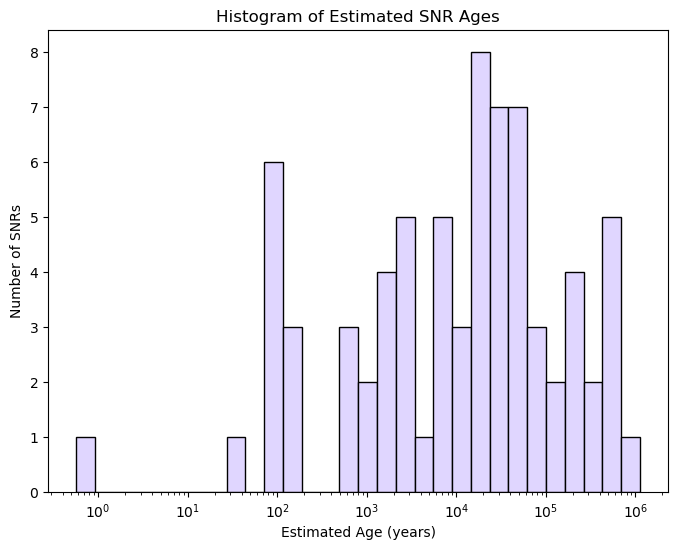

In [12]:
plt.figure(figsize=(8, 6))

bins = np.logspace(np.log10(snr_longitude_filtered_df['t_yr'].min()),
                   np.log10(snr_longitude_filtered_df['t_yr'].max()),
                   31)

plt.hist(snr_longitude_filtered_df['t_yr'], bins=bins, color = '#e0d6ff', edgecolor='black')
plt.xscale('log')

plt.xlabel('Estimated Age (years)')
plt.ylabel('Number of SNRs')
plt.title('Histogram of Estimated SNR Ages')

plt.show()

### Interpretation of the Age Histogram

The histogram of estimated ages spans a wide range, with a few very young outliers and most supernova remnants distributed broadly from about $10^2$ to $10^6$ years. This broad range is expected in part because the Sedov-Taylor age depends strongly on radius, with $t \propto R^{5/2}$. The histogram is therefore useful for comparing the relative spread of the estimated ages, but the absolute values should be treated with caution.

The histogram is only partly plausible physically. The Sedov-Taylor relation is most appropriate for remnants in the intermediate adiabatic expansion stage, typically on the order of about $10^4\,\mathrm{years}$ (https://arxiv.org/html/2405.17384v1). The extreme age estimates should be treated cautiously, since the youngest remnant in the sample has an estimated age of about $10^0 \,\mathrm{years}$, while the oldest has an estimated age of about $10^6 \,\mathrm{years}$. Very young remnants may not yet be in the Sedov-Taylor phase, while very old remnants may have evolved beyond the stage where the Sedov-Taylor relation is a good approximation.

The Sedov-Taylor equation also has several limitations in this context:

- it assumes an ideal adiabatic blast wave
- it assumes all remnants are in the Sedov–Taylor phase
- it uses the same explosion energy for every remnant
- it uses the same ambient density for every remnant
- the physical radius depends on an assumed distance, so any error in distance propagates directly into the age estimate

---

## Filter the SNR Catalog Again

1. Read the filtered SNR catalog from `snr_longitude_filtered_df.csv` into a pandas DataFrame called `df`.
2. Select only the rows with valid flux density values in `FluxDensity_Jy`, excluding entries marked as `Null`.
3. Save the filtered results to a new file, `snr_flux_filtered_df.csv`.

This produces the subset of remnants used for the rest of the analysis.

In [13]:
df = pd.read_csv("snr_longitude_filtered_df.csv")

if 'snr_flux_filtered_df' not in globals():
    snr_flux_filtered_df = df[df['FluxDensity_Jy'] != "Null"].copy()
    snr_flux_filtered_df.to_csv("snr_flux_filtered_df.csv", index=False)

---
## Radio Flux Versus SNR Size

This section examines how the radio flux densities $S$ of the selected supernova remnants vary with their size.

Two measures of size are used:

- the angular diameter, $\theta$, in arcminutes
- the linear radius, $R$, in cm

The resulting plots show radio flux as a function of angular size and linear radius.

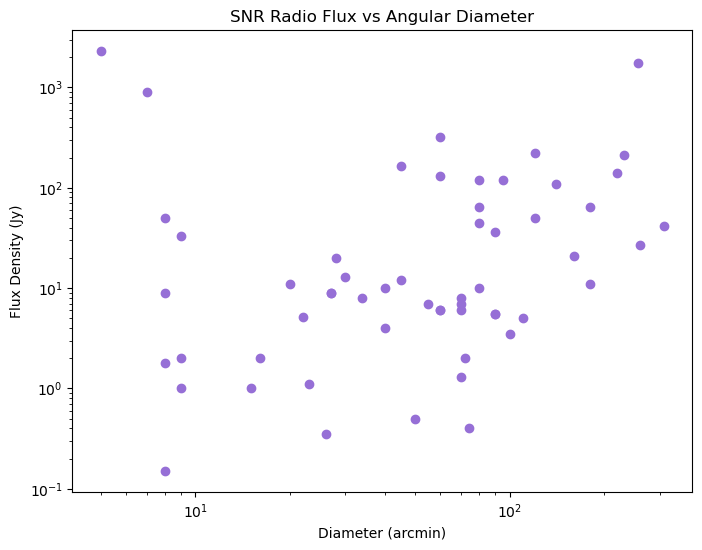

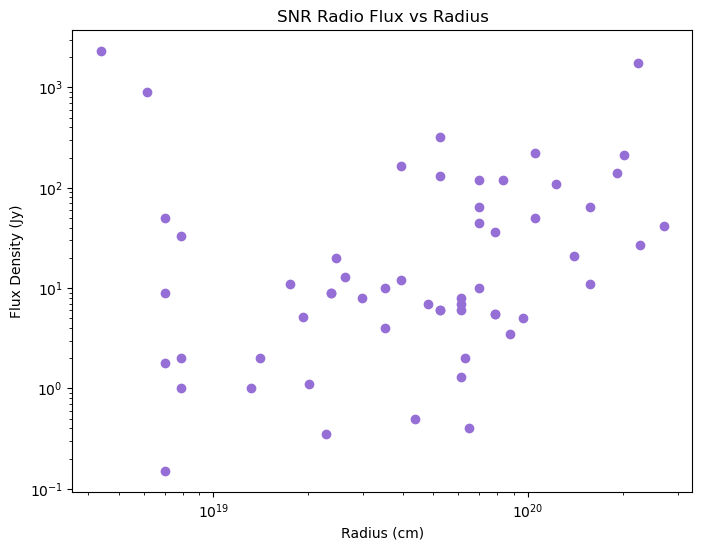

Correlation for flux vs angular diameter: 0.2650799503622265
Correlation for flux vs linear radius: 0.2650799503622264


In [14]:
d = 6.02 * 10**21  # units: cm

# Helper function to calculate R given angular radius in radians
def calculate_R(theta):
    return theta * d

# Calculate R
theta_arcmin = snr_flux_filtered_df['Diameter_arcmin'] / 2               # calculate angular radius in arcmin
theta_rad = theta_arcmin * (np.pi / 180) / 60                            # convert angular radius to radians
snr_flux_filtered_df['R_cm'] = calculate_R(theta_rad)                    # calculate linear radius 

snr_flux_filtered_df['FluxDensity_Jy'] = pd.to_numeric(snr_flux_filtered_df['FluxDensity_Jy'])

# Flux vs angular diameter (arcmin)
plt.figure(figsize=(8, 6))
plt.scatter(snr_flux_filtered_df['Diameter_arcmin'], snr_flux_filtered_df['FluxDensity_Jy'], color = '#966FD6')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Diameter (arcmin)')
plt.ylabel('Flux Density (Jy)')
plt.title('SNR Radio Flux vs Angular Diameter')
plt.show()

# Flux vs radius (cm)
plt.figure(figsize=(8, 6))
plt.scatter(snr_flux_filtered_df['R_cm'], snr_flux_filtered_df['FluxDensity_Jy'], color = '#966FD6')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Radius (cm)')
plt.ylabel('Flux Density (Jy)')
plt.title('SNR Radio Flux vs Radius')
plt.show()

# Calculate correlation coefficients
x = np.log10(snr_flux_filtered_df['Diameter_arcmin'])
y = np.log10(snr_flux_filtered_df['FluxDensity_Jy'])
corr_diameter = np.corrcoef(x, y)[0, 1]

a = np.log10(snr_flux_filtered_df['R_cm'])
b = np.log10(snr_flux_filtered_df['FluxDensity_Jy'])
corr_radius = np.corrcoef(a, b)[0, 1]

print("Correlation for flux vs angular diameter:", corr_diameter)
print("Correlation for flux vs linear radius:", corr_radius)

### Interpretation of the Flux Versus Size Plots

The radio flux versus size plots do not show a strong trend. There is substantial scatter, indicating that flux is not determined by size alone. The log-space correlation coefficient is about 0.27 for both flux versus angular diameter and flux versus physical radius, which suggests only a weak positive relationship. Some larger remnants do have relatively high fluxes, but the overall distribution does not indicate a tight correlation.

This is reasonable physically, since the observed radio flux can also depend on factors such as distance, environment, magnetic field strength, particle acceleration efficiency, and evolutionary stage. Size is therefore only one factor among many that can affect the observed radio emission.

---
## Histogram of Radio Flux Divided by SNR Area

This section calculates the radio flux $S$ divided by the area of each supernova remnant and plots the resulting distribution as a histogram.

Two corresponding area measures are used, treating each remnant as circular:

- the angular area $A_{\rm ang}$, in arcmin$^2$
- the physical area $A_{\rm phys}$, in cm$^2$

These histograms show how flux per unit area is distributed across the selected sample.

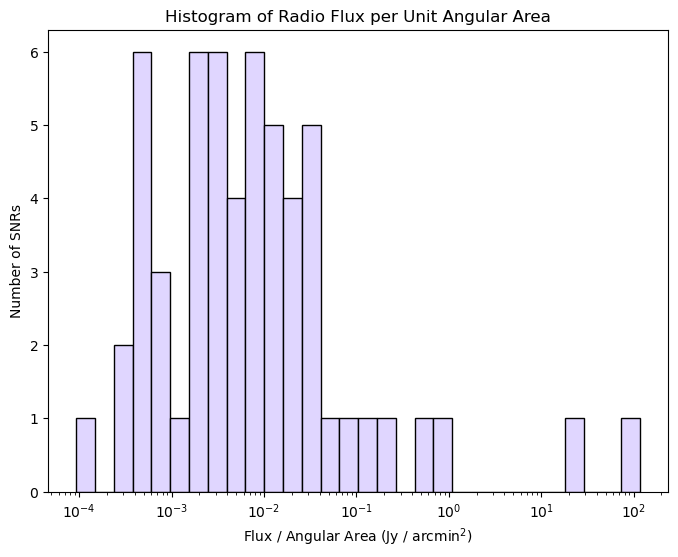

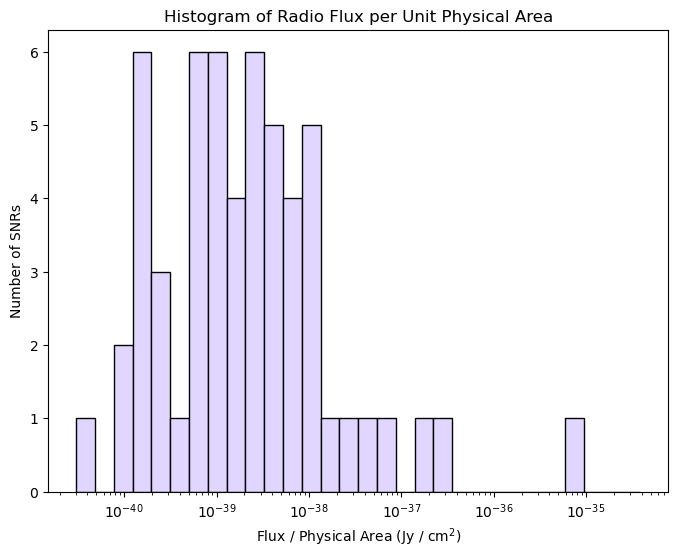

In [33]:
# Calculate angular area
A_ang = np.pi * (snr_flux_filtered_df['Diameter_arcmin'] / 2)**2
snr_flux_filtered_df['A_ang'] = A_ang 

# Calculate physical area
A_phys = np.pi * (snr_flux_filtered_df['R_cm'])**2
snr_flux_filtered_df['A_phys'] = A_phys

snr_flux_filtered_df['FluxDensity_Jy'] = pd.to_numeric(snr_flux_filtered_df['FluxDensity_Jy'])

snr_flux_filtered_df['Sigma_ang'] = snr_flux_filtered_df['FluxDensity_Jy'] / snr_flux_filtered_df['A_ang']
snr_flux_filtered_df['Sigma_'] = snr_flux_filtered_df['FluxDensity_Jy'] / snr_flux_filtered_df['A_phys']

# Flux / angular area
plt.figure(figsize=(8, 6))

bins_ang = np.logspace(np.log10(snr_flux_filtered_df['Sigma_ang'].min()),
                   np.log10(snr_flux_filtered_df['Sigma_ang'].max()),
                   31)

plt.hist(snr_flux_filtered_df['Sigma_ang'], bins=bins_ang, color = '#e0d6ff', edgecolor='black')
plt.xscale('log')

plt.xlabel('Flux / Angular Area (Jy / arcmin$^2$)')
plt.ylabel('Number of SNRs')
plt.title('Histogram of Radio Flux per Unit Angular Area')

plt.show()

# Flux / physical area
plt.figure(figsize=(8, 6))

bins_phys = np.logspace(np.log10(snr_flux_filtered_df['flux_per_A_phys'].min()),
                   np.log10(snr_flux_filtered_df['flux_per_A_phys'].max()),
                   31)

plt.hist(snr_flux_filtered_df['flux_per_A_phys'], bins=bins_phys, color = '#e0d6ff', edgecolor='black')
plt.xscale('log')

plt.xlabel('Flux / Physical Area (Jy / cm$^2$)')
plt.ylabel('Number of SNRs')
plt.title('Histogram of Radio Flux per Unit Physical Area')

plt.show()

### Interpretation of the Flux-Per-Area Histogram

The histogram of radio flux divided by area is strongly skewed toward low values, with only a small number of remnants extending to much larger flux-per-area values. This indicates that most supernova remnants in the sample are relatively faint per unit area, while a few are much brighter for their size.

This suggests that many remnants are fairly diffuse radio emitters, whereas a smaller number have comparatively strong surface brightness. The spread in the histogram also shows that the remnants do not all have similar radio brightness per unit area, even after differences in size are taken into account.

---

## Final Filtered SNR Data Tables

In [16]:
print("SNRs filtered by galactic longitude (60° ≤ l ≤ 270°)")
display(snr_longitude_filtered_df)

print("SNRs with valid flux values")
display(snr_flux_filtered_df)

SNRs filtered by galactic longitude (60° ≤ l ≤ 270°)


,SNR name,RA_deg,Dec_deg,l_deg,b_deg,Diameter_arcmin,FluxDensity_Jy,Table,Catalog,theta_rad,R_cm,t_s,t_yr
131,G266.2-1.2,132.959600,-46.257600,266.183,-1.193,103.0,Null,1,MeerKAT,0.014981,9.018407e+19,1.937976e+12,61452.815021
282,G267.0-1.0,133.900400,-46.737600,266.967,-1.005,1.0,Null,2,MeerKAT,0.000145,8.755735e+17,1.799929e+07,0.570754
283,G269.7+0.0,137.665700,-48.045100,269.638,0.030,43.0,Null,2,MeerKAT,0.006254,3.764966e+19,2.182360e+11,6920.219326
435,G257.408-00.162,126.810000,-38.669200,257.408,-0.162,71.2,Null,4,MeerKAT,0.010356,6.234083e+19,7.699372e+11,24414.548885
436,G259.683-01.235,127.407600,-41.142200,259.683,-1.235,15.4,Null,4,MeerKAT,0.002240,1.348383e+19,1.675163e+10,531.190772
...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,G249.5+24.5,143.500000,-17.000000,249.500,24.500,260.0,27.0,1,Green,0.037815,2.276491e+20,1.961953e+13,622131.354851
819,G260.4-3.4,125.541667,-43.000000,260.400,-3.400,60.0,130.0,1,Green,0.008727,5.253441e+19,5.019188e+11,15915.740370
820,G261.9+5.5,136.083333,-38.700000,261.900,5.500,40.0,10.0,1,Green,0.005818,3.502294e+19,1.821400e+11,5775.621153
821,G263.9-3.3,128.500000,-45.833333,263.900,-3.300,255.0,1750.0,1,Green,0.037088,2.232712e+20,1.868985e+13,592651.204093


SNRs with valid flux values


,SNR name,RA_deg,Dec_deg,l_deg,b_deg,Diameter_arcmin,FluxDensity_Jy,Table,Catalog,R_cm,A_ang,A_phys,flux_per_A_ang,flux_per_A_phys
5,G63.7+1.1,296.966667,27.750000,63.7,1.1,8.0,1.80,1,Green,7.004588e+18,50.265482,1.541399e+38,0.035810,1.167770e-38
6,G64.5+0.9,297.604167,28.266667,64.5,0.9,8.0,0.15,1,Green,7.004588e+18,50.265482,1.541399e+38,0.002984,9.731419e-40
7,G65.1+0.6,298.666667,28.583333,65.1,0.6,90.0,5.50,1,Green,7.880162e+19,6361.725124,1.950833e+40,0.000865,2.819308e-40
8,G65.3+5.7,293.250000,31.166667,65.3,5.7,310.0,42.00,1,Green,2.714278e+20,75476.763502,2.314507e+41,0.000556,1.814641e-40
9,G65.7+1.2,298.041667,29.433333,65.7,1.2,22.0,5.10,1,Green,1.926262e+19,380.132711,1.165683e+39,0.013416,4.375117e-39
12,G67.7+1.8,298.633333,31.483333,67.7,1.8,15.0,1.00,1,Green,1.313360e+19,176.714587,5.418981e+38,0.005659,1.845365e-39
14,G68.6-1.2,302.166667,30.616667,68.6,-1.2,23.0,1.10,1,Green,2.013819e+19,415.475628,1.274063e+39,0.002648,8.633799e-40
15,G69.0+2.7,298.333333,32.916667,69.0,2.7,80.0,120.00,1,Green,7.004588e+19,5026.548246,1.541399e+40,0.023873,7.785135e-39
16,G69.7+1.0,300.666667,32.716667,69.7,1.0,16.0,2.00,1,Green,1.400918e+19,201.061930,6.165596e+38,0.009947,3.243806e-39
18,G73.9+0.9,303.562500,36.200000,73.9,0.9,27.0,9.00,1,Green,2.364048e+19,572.555261,1.755750e+39,0.015719,5.126015e-39


---
## Extra Credit: Sedov–Taylor Expansion Velocity Check

As an additional consistency check, the expansion velocity implied by the Sedov–Taylor age estimates can be calculated. For a remnant evolving in the Sedov–Taylor phase,

$$
R(t) = \left( \frac{25}{3\pi} \right)^{1/5} \left(\frac{E_{\text{SN}}}{\rho_0}\right)^{1/5} t^{2/5},
$$

so the expansion velocity is given by

$$
v(t) = \frac{dR}{dt} = \frac{2}{5} \left( \frac{25}{3\pi} \right)^{1/5} \left(\frac{E_{\text{SN}}}{\rho_0}\right)^{1/5} t^{-3/5} = \frac{2R}{5t}.
$$

This provides a way to test whether the inferred ages correspond to physically plausible expansion speeds. Extremely large or small inferred velocities may indicate that the assumed distance, explosion energy, ambient density, or Sedov–Taylor phase approximation is not appropriate for some remnants.

In [32]:
# Calculate v
v = (2 * snr_longitude_filtered_df['R_cm']) / (5 * snr_longitude_filtered_df['t_s'])     # calculate velocity
snr_longitude_filtered_df['v_cm/s'] = v
snr_longitude_filtered_df['v_km/s'] = snr_longitude_filtered_df['v_cm/s'] / 100000
with pd.option_context('display.max_rows', None):
    display(snr_longitude_filtered_df[['v_cm/s', 'v_km/s']])
    
min_v = snr_longitude_filtered_df['v_cm/s'].min()
max_v = snr_longitude_filtered_df['v_cm/s'].max()

print("Minimum velocity (cm/s):", min_v)
print("Maximum velocity (cm/s):", max_v)

print("Minimum velocity (km/s):", min_v/100000)
print("Maximum velocity (km/s):", max_v/100000)

,v_cm/s,v_km/s
131,1.861407e+07,186.140742
282,1.945796e+10,194579.586966
283,6.900723e+07,690.072298
435,3.238749e+07,323.874896
436,3.219706e+08,3219.705844
754,8.599284e+08,8599.284089
755,8.599284e+08,8599.284089
756,2.278943e+07,227.894326
757,3.564961e+06,35.649606
758,1.885659e+08,1885.659424


Minimum velocity (cm/s): 3245834.4648975786
Maximum velocity (cm/s): 19457958696.638214
Minimum velocity (km/s): 32.45834464897579
Maximum velocity (km/s): 194579.58696638214


### Interpretation of Velocity

Most inferred expansion velocities fall within the rough range expected for supernova remnants (hundreds to several thousand $\mathrm{km\,s^{-1}}$), but several objects yield unrealistically large velocities, including values approaching a significant fraction of the speed of light ($0.65c$). This indicates that the simplifying assumptions used in the Sedov–Taylor age calculation are not valid for all remnants in the sample. These unrealistic velocities likely arise because the simplifying assumptions used in the age calculation are not valid for every object in the sample. In particular, some remnants may not actually lie in the Perseus arm, meaning the assumed common distance produces incorrect physical sizes. Others may be too young or too old for the Sedov–Taylor approximation to apply, or may evolve in environments with densities significantly different from the assumed uniform ambient density. Variations in explosion energy between remnants would also affect the inferred ages and therefore the calculated expansion velocities.

---
## Extra Credit: Surface Brightness–Diameter Relation

As a second extension beyond the original project scope, the radio surface brightness was compared with remnant diameter. This is related to the commonly used surface brightness–diameter, or $\Sigma-D$, relation for supernova remnants.

The radio surface brightness is defined as

$$
\Sigma = \frac{S}{A_{\rm ang}},
$$

where $S$ is the radio flux density and $A_{\rm ang}$ is the angular area of the remnant.

The physical diameter was calculated from the estimated physical radius as

$$
D = 2R.
$$

A decreasing trend would be physically reasonable because larger remnants are often older and more diffuse, so their radio emission is spread over a larger area. However, scatter is expected because radio surface brightness also depends on environmental density, magnetic-field strength, shock acceleration efficiency, distance uncertainty, and catalog selection effects.

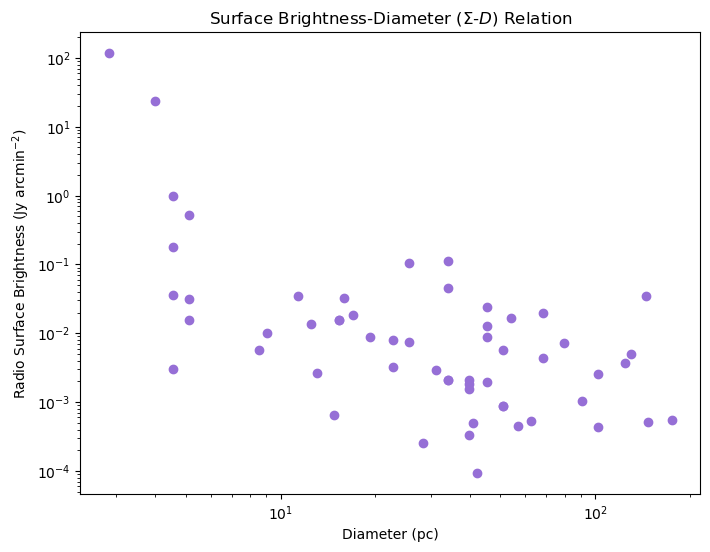

In [38]:
# Extra Credit: Surface Brightness-Diameter relation

# Physical radius in pc
snr_flux_filtered_df['R_pc'] = snr_flux_filtered_df['R_cm'] / 3.086e18

# Physical diameter in pc
snr_flux_filtered_df['D_pc'] = 2 * snr_flux_filtered_df['R_pc']

# Radio surface brightness
snr_flux_filtered_df['Sigma'] = snr_flux_filtered_df['flux_per_A_ang']

# Surface Brightness (Jy/ acrmin^2) vs diameter (pc)
plt.figure(figsize=(8, 6))
plt.scatter(snr_flux_filtered_df['D_pc'], snr_flux_filtered_df['Sigma'], color = '#966FD6')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Diameter (pc)')
plt.ylabel(r'Radio Surface Brightness (Jy arcmin$^{-2}$)')
plt.title(r'Surface Brightness-Diameter ($\Sigma$-$D$) Relation')
plt.show()

### Interpretation of $\Sigma$-$D$ plot

The $\Sigma$-$D$ plot shows an overall inverse relationship between radio surface brightness and physical diameter. Smaller remnants tend to have higher radio surface brightness, while larger remnants are generally fainter per unit angular area. This trend is physically reasonable because younger, more compact remnants often have stronger shocks and more concentrated synchrotron emission, whereas older remnants expand, become more diffuse, and spread their emission over a larger area.

There is also substantial scatter about this trend, indicating that diameter alone does not determine radio surface brightness. Variations in ambient density, magnetic-field strength, shock acceleration efficiency, and distance uncertainty likely all contribute to the observed spread.